In [1]:
import pickle
import os
from ChannelViT.utils import calculate_per_channel_stats, just_transform_with_norm
import numpy as _np
filtered_data_path = os.path.join('Data/images', "filtered_data.pkl")
if os.path.exists(filtered_data_path):
    with open(filtered_data_path, "rb") as f:
        filtered_data = pickle.load(f)
    print(f"Filtered data loaded from {filtered_data_path}")

filtered_data['data_Website_Ralf_filtered']


# Visualise these images per class  in one hot encoding  filtered_data['data_Website_filtered'] filtered_data['data_Website_Ralf_filtered']



 

/Users/eagle/Documents/eagle-classification/venv_eagle_class/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/eagle/Documents/eagle-classification/venv_eagle_class/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Filtered data loaded from Data/images/filtered_data.pkl


[(array([[[ 12, 111, 194, ..., 118, 134, 130],
          [ 16, 101, 186, ..., 116, 132, 128],
          [ 18, 109, 191, ..., 116, 132, 127],
          ...,
          [  8,  59, 130, ...,  83,  93,  92],
          [  8,  84, 162, ...,  86,  96,  93],
          [  6, 103, 180, ...,  81,  92,  91]],
  
         [[ 12, 105, 189, ..., 119, 135, 131],
          [ 18, 104, 188, ..., 118, 134, 130],
          [ 20, 104, 187, ..., 117, 133, 129],
          ...,
          [  6,  81, 160, ...,  83,  94,  92],
          [  8,  78, 155, ...,  84,  94,  92],
          [  6,  88, 165, ...,  84,  94,  93]],
  
         [[ 14,  83, 170, ..., 119, 135, 131],
          [ 18,  82, 168, ..., 119, 136, 132],
          [ 22, 101, 184, ..., 120, 136, 132],
          ...,
          [  8, 102, 182, ...,  84,  94,  93],
          [  6,  98, 176, ...,  84,  94,  92],
          [  6,  96, 173, ...,  85,  95,  94]],
  
         ...,
  
         [[ 14, 135, 214, ..., 255, 255, 255],
          [ 16, 116, 194, ..., 25

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import math

label_names = {
    0: 'good',
    1: 'crack',
    2: 'cross',
    3: 'dark',
    4: 'corrosion',
    5: 'discoloration',
    6: 'delamination',
}

def visualize_all_samples(data, title, save_path):
    """Visualize all samples grouped by class (first channel only)."""
    # Group by class
    classes = {i: [] for i in range(7)}
    for img, label in data:
        class_idx = int(np.argmax(label))
        # Extract first channel
        if img.ndim == 3:
            img_ch0 = img[:, :, 0]
        else:
            img_ch0 = img
        classes[class_idx].append(img_ch0)
    
    # Print statistics
    print(f"\n{title} - Class distribution:")
    for idx, name in label_names.items():
        print(f"  {name:15s}: {len(classes[idx]):4d} samples")
    
    # Create separate figure for each class
    for class_idx in range(7):
        samples = classes[class_idx]
        if len(samples) == 0:
            continue
            
        # Calculate grid size (aim for roughly square grid)
        n_samples = len(samples)
        n_cols = min(10, n_samples)  # max 10 columns
        n_rows = math.ceil(n_samples / n_cols)
        
        fig, axes = plt.subplots(n_rows, n_cols, 
                                figsize=(n_cols * 2, n_rows * 2))
        fig.suptitle(f"{title} - {label_names[class_idx]} (n={n_samples})", 
                    fontsize=14)
        
        # Flatten axes for easier iteration
        if n_rows == 1 and n_cols == 1:
            axes = np.array([axes])
        axes_flat = axes.flatten() if n_rows > 1 or n_cols > 1 else axes
        
        for idx, (ax, img) in enumerate(zip(axes_flat, samples)):
            ax.imshow(img, cmap='gray')
            ax.axis('off')
        
        # Hide unused subplots
        for idx in range(len(samples), len(axes_flat)):
            axes_flat[idx].axis('off')
        
        plt.tight_layout()
        class_save_path = save_path.replace('.png', f'_class_{class_idx}_{label_names[class_idx]}.png')
        plt.savefig(class_save_path, dpi=100, bbox_inches='tight')
        plt.close()
        print(f"  Saved {label_names[class_idx]} visualization to {class_save_path}")

# Visualize first dataset
visualize_all_samples(
    filtered_data['data_Website_filtered'],
    'Website Filtered Dataset (Channel 0)',
    'Data/images/website_filtered_all_ch0.png'
)

# Visualize second dataset
visualize_all_samples(
    filtered_data['data_Website_Ralf_filtered'],
    'Website Ralf Filtered Dataset (Channel 0)',
    'Data/images/website_ralf_filtered_all_ch0.png'
)


Website Filtered Dataset (Channel 0) - Class distribution:
  good           :   32 samples
  crack          :   32 samples
  cross          :   16 samples
  dark           :  107 samples
  corrosion      :    6 samples
  discoloration  :   41 samples
  delamination   :    0 samples
  Saved good visualization to Data/images/website_filtered_all_ch0_class_0_good.png
  Saved crack visualization to Data/images/website_filtered_all_ch0_class_1_crack.png
  Saved cross visualization to Data/images/website_filtered_all_ch0_class_2_cross.png
  Saved dark visualization to Data/images/website_filtered_all_ch0_class_3_dark.png
  Saved corrosion visualization to Data/images/website_filtered_all_ch0_class_4_corrosion.png
  Saved discoloration visualization to Data/images/website_filtered_all_ch0_class_5_discoloration.png

Website Ralf Filtered Dataset (Channel 0) - Class distribution:
  good           :   62 samples
  crack          :   53 samples
  cross          :   20 samples
  dark           : 

In [11]:
import matplotlib.pyplot as plt
import os

def plot_images_by_label(data, title, save_dir):
    """Plot one image per file grouped by label."""
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    # Group images by label
    classes = {i: [] for i in range(7)}
    for img, label in data:
        class_idx = int(np.argmax(label))
        # Extract first channel
        if img.ndim == 3:
            img_ch0 = img[:, :, 0]
        else:
            img_ch0 = img
        classes[class_idx].append(img_ch0)

    # Plot images
    for class_idx, images in classes.items():
        for idx, img in enumerate(images):
            plt.figure()
            plt.imshow(img, cmap='gray')
            plt.axis('off')
            plt.savefig(os.path.join(save_dir, f"{title.replace(' ', '_')}_class_{class_idx}_img_{idx}.png"), dpi=100, bbox_inches='tight')
            plt.close()

# Plot images for both datasets
plot_images_by_label(
    filtered_data['data_Website_filtered'],
    'Website Filtered Dataset',
    'Data/images/website_filtered_images'
)

plot_images_by_label(
    filtered_data['data_Website_Ralf_filtered'],
    'Website Ralf Filtered Dataset',
    'Data/images/website_ralf_filtered_images'
)

In [8]:
import numpy as np
from collections import defaultdict

def find_duplicate_images(data1, data2, dataset1_name, dataset2_name):
    """Find identical images between two datasets."""
    
    # Create hash dictionary for first dataset
    hash_dict = defaultdict(list)
    
    print(f"\nHashing images from {dataset1_name}...")
    for idx, (img, label) in enumerate(data1):
        # Convert to bytes for hashing
        img_bytes = img.tobytes()
        img_hash = hash(img_bytes)
        hash_dict[img_hash].append(('data1', idx, label))
    
    print(f"Checking for duplicates in {dataset2_name}...")
    duplicates = []
    
    for idx, (img, label) in enumerate(data2):
        img_bytes = img.tobytes()
        img_hash = hash(img_bytes)
        
        if img_hash in hash_dict:
            # Found potential duplicate, verify with numpy comparison
            for ref_dataset, ref_idx, ref_label in hash_dict[img_hash]:
                ref_img = data1[ref_idx][0]
                if np.array_equal(img, ref_img):
                    duplicates.append({
                        'dataset1_idx': ref_idx,
                        'dataset2_idx': idx,
                        'dataset1_label': np.argmax(ref_label),
                        'dataset2_label': np.argmax(label),
                        'labels_match': np.array_equal(ref_label, label)
                    })
    
    return duplicates

# Find duplicates
duplicates = find_duplicate_images(
    filtered_data['data_Website_filtered'],
    filtered_data['data_Website_Ralf_filtered'],
    'data_Website_filtered',
    'data_Website_Ralf_filtered'
)

# Report results
print(f"\n{'='*60}")
print(f"DUPLICATE ANALYSIS")
print(f"{'='*60}")
print(f"Total duplicates found: {len(duplicates)}")

if len(duplicates) > 0:
    print(f"\nDuplicate details:")
    for i, dup in enumerate(duplicates[:10]):  # Show first 10
        print(f"\n  Duplicate {i+1}:")
        print(f"    Dataset1 index: {dup['dataset1_idx']} (class: {label_names[dup['dataset1_label']]})")
        print(f"    Dataset2 index: {dup['dataset2_idx']} (class: {label_names[dup['dataset2_label']]})")
        print(f"    Labels match: {dup['labels_match']}")
    
    if len(duplicates) > 10:
        print(f"\n  ... and {len(duplicates) - 10} more duplicates")
    
    # Summary by label match
    labels_match_count = sum(1 for d in duplicates if d['labels_match'])
    labels_differ_count = len(duplicates) - labels_match_count
    print(f"\n  Duplicates with matching labels: {labels_match_count}")
    print(f"  Duplicates with different labels: {labels_differ_count}")
else:
    print("\nNo duplicate images found between the datasets.")

print(f"{'='*60}\n")


Hashing images from data_Website_filtered...
Checking for duplicates in data_Website_Ralf_filtered...

DUPLICATE ANALYSIS
Total duplicates found: 0

No duplicate images found between the datasets.




Most similar pairs:

  Pair 1:
    Dataset1 index: 2 (class: good)
    Dataset2 index: 11 (class: good)
    Distance: 0.0000
    Labels match: True

  Pair 2:
    Dataset1 index: 7 (class: good)
    Dataset2 index: 11 (class: good)
    Distance: 0.0000
    Labels match: True

  Pair 3:
    Dataset1 index: 9 (class: good)
    Dataset2 index: 11 (class: good)
    Distance: 0.0000
    Labels match: True

  Pair 4:
    Dataset1 index: 11 (class: good)
    Dataset2 index: 11 (class: good)
    Distance: 0.0000
    Labels match: True

  Pair 5:
    Dataset1 index: 17 (class: dark)
    Dataset2 index: 11 (class: good)
    Distance: 0.0000
    Labels match: False

  Pair 6:
    Dataset1 index: 19 (class: dark)
    Dataset2 index: 11 (class: good)
    Distance: 0.0000
    Labels match: False

  Pair 7:
    Dataset1 index: 21 (class: dark)
    Dataset2 index: 11 (class: good)
    Distance: 0.0000
    Labels match: False

  Pair 8:
    Dataset1 index: 25 (class: dark)
    Dataset2 index: 11 (clas

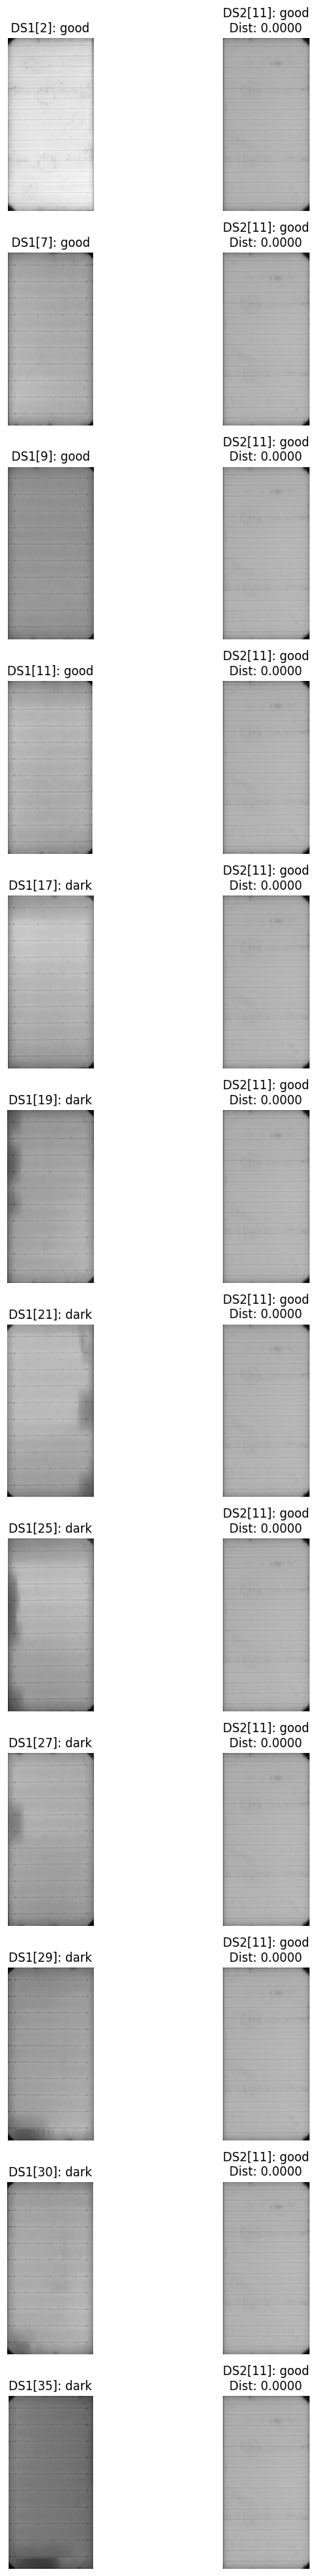


  Exact matches (distance=0): 796
  Similar pairs with matching labels: 3045
  Similar pairs with different labels: 16483


In [7]:
# ...existing code...
if len(similar_pairs) > 0:
    # Sort by distance
    similar_pairs.sort(key=lambda x: x['distance'])
    
    print(f"\nMost similar pairs:")
    for i, pair in enumerate(similar_pairs[:10]):
        print(f"\n  Pair {i+1}:")
        print(f"    Dataset1 index: {pair['dataset1_idx']} (class: {label_names[int(pair['dataset1_label'])]})")
        print(f"    Dataset2 index: {pair['dataset2_idx']} (class: {label_names[int(pair['dataset2_label'])]})")
        print(f"    Distance: {pair['distance']:.4f}")
        print(f"    Labels match: {pair['labels_match']}")
    
    # Visualize top 12 most similar pairs
    n_show = min(12, len(similar_pairs))
    fig, axes = plt.subplots(n_show, 2, figsize=(8, n_show * 3))
    if n_show == 1:
        axes = axes.reshape(1, -1)
    
    for i, pair in enumerate(similar_pairs[:n_show]):
        img1, label1 = filtered_data['data_Website_filtered'][pair['dataset1_idx']]
        img2, label2 = filtered_data['data_Website_Ralf_filtered'][pair['dataset2_idx']]
        
        # Extract first channel
        img1_ch0 = img1[:, :, 0] if img1.ndim == 3 else img1
        img2_ch0 = img2[:, :, 0] if img2.ndim == 3 else img2
        
        axes[i, 0].imshow(img1_ch0, cmap='gray')
        axes[i, 0].set_title(f"DS1[{pair['dataset1_idx']}]: {label_names[int(pair['dataset1_label'])]}")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(img2_ch0, cmap='gray')
        axes[i, 1].set_title(f"DS2[{pair['dataset2_idx']}]: {label_names[int(pair['dataset2_label'])]}\nDist: {pair['distance']:.4f}")
        axes[i, 1].axis('off')
    
    plt.tight_layout()
    plt.savefig('Data/images/similar_pairs.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Summary statistics
    exact_matches = sum(1 for p in similar_pairs if p['distance'] == 0)
    labels_match_count = sum(1 for p in similar_pairs if p['labels_match'])
    labels_differ_count = len(similar_pairs) - labels_match_count
    
    print(f"\n  Exact matches (distance=0): {exact_matches}")
    print(f"  Similar pairs with matching labels: {labels_match_count}")
    print(f"  Similar pairs with different labels: {labels_differ_count}")
# ...existing code...